# Estimated sweat loss and residual T-shirt moisture

This notebook compares two distinct outcomes across the three ventilation conditions:

1. **Estimated sweat loss**, calculated from the decrease in body mass because no fluid was consumed and no urine was produced during the trials.
2. **Residual moisture retained by the T-shirt**, calculated from the increase in T-shirt mass.

The first quantity is an estimate rather than a direct measurement of sweat secretion because respiratory and metabolic mass exchanges are not corrected. It also assumes that pre- and post-trial body masses were measured under comparable conditions without wet garments.


## 1. Configuration

The primary analysis uses absolute masses in grams. Body-mass-normalised sweat loss is exported as a secondary descriptive outcome. Two-sided exact sign-flip tests compare low and high ventilation with no ventilation. Holm adjustment is applied separately to the two planned contrasts for each primary outcome.


In [1]:
from pathlib import Path
import itertools
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from scipy import stats


CONDITION_ORDER = ["no_ventilation", "low_ventilation", "high_ventilation"]
CONDITION_LABELS = {
    "no_ventilation": "No ventilation",
    "low_ventilation": "Low ventilation",
    "high_ventilation": "High ventilation",
}
CONDITION_COLORS = {
    "no_ventilation": "blue",
    "low_ventilation": "red",
    "high_ventilation": "black",
}

# Values failing the mass-balance checks remain in the exported clean table,
# but are omitted from the corresponding primary inferential comparison.
EXCLUDE_MASS_BALANCE_FLAGS = True


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "outputs").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
INPUT_CANDIDATES = [
    PROJECT_ROOT / "data/raw/subjective_questionnaires_restructured.xlsx",
    PROJECT_ROOT / "outputs/subjective_questionnaires/subjective_questionnaires_restructured.xlsx",
    Path("/home/eleonorab/repository/convective_cooling/data/raw/subjective_questionnaires_restructured.xlsx"),
]
INPUT_FILE = next((p for p in INPUT_CANDIDATES if p.exists()), None)
if INPUT_FILE is None:
    raise FileNotFoundError("Workbook not found. Checked:\n" + "\n".join(map(str, INPUT_CANDIDATES)))

OUTPUT_DIR = PROJECT_ROOT / "reports/08_sweat_mass_balance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input: {INPUT_FILE}")
print(f"Output: {OUTPUT_DIR}")


Input: /home/eleonorab/repository/convective_cooling/data/raw/subjective_questionnaires_restructured.xlsx
Output: /home/eleonorab/repository/convective_cooling/reports/08_sweat_mass_balance


## 2. Controlled extraction and quality checks

The source workbook records garment names and masses in text fields whose order is not identical in every trial. The code identifies the position of *maglia* in the initial garment description and extracts the number in the same position from the pre- and post-trial mass fields. The original text is retained in the output so that every extraction can be checked manually.


In [2]:
def extract_numbers(value):
    if pd.isna(value):
        return []
    normalised = str(value).replace(",", ".")
    return [float(x) for x in re.findall(r"(?<!\d)(\d+(?:\.\d+)?)(?!\d)", normalised)]


def shirt_position(description):
    if pd.isna(description):
        return np.nan
    parts = [part.strip().lower() for part in str(description).split(",")]
    matches = [i for i, part in enumerate(parts) if "maglia" in part]
    return matches[0] if len(matches) == 1 else np.nan


weights = pd.read_excel(INPUT_FILE, sheet_name="weights_review")
required = {
    "trial_id", "subject_id", "condition", "initial_body_mass_kg",
    "final_body_mass_kg", "clothing_description_raw",
    "initial_clothing_mass_raw", "final_clothing_mass_raw",
}
missing = required.difference(weights.columns)
if missing:
    raise ValueError(f"Missing columns in weights_review: {sorted(missing)}")

rows = []
for row in weights.to_dict("records"):
    position = shirt_position(row["clothing_description_raw"])
    initial_values = extract_numbers(row["initial_clothing_mass_raw"])
    final_values = extract_numbers(row["final_clothing_mass_raw"])
    extraction_ok = (
        pd.notna(position)
        and int(position) < len(initial_values)
        and int(position) < len(final_values)
        and len(initial_values) == len(final_values) == 4
    )
    shirt_pre = initial_values[int(position)] if extraction_ok else np.nan
    shirt_post = final_values[int(position)] if extraction_ok else np.nan
    sweat_loss = (row["initial_body_mass_kg"] - row["final_body_mass_kg"]) * 1000
    retained = shirt_post - shirt_pre if extraction_ok else np.nan
    rows.append({
        **row,
        "shirt_position_zero_based": position,
        "shirt_mass_pre_g": shirt_pre,
        "shirt_mass_post_g": shirt_post,
        "shirt_retained_moisture_g": retained,
        "estimated_sweat_loss_g": sweat_loss,
        "estimated_sweat_loss_g_per_kg": sweat_loss / row["initial_body_mass_kg"],
        "shirt_extraction_ok": extraction_ok,
        "flag_nonpositive_sweat_loss": bool(np.isfinite(sweat_loss) and sweat_loss <= 0),
        "flag_negative_shirt_moisture": bool(np.isfinite(retained) and retained < 0),
        "flag_shirt_exceeds_sweat": bool(
            np.isfinite(retained) and np.isfinite(sweat_loss)
            and sweat_loss > 0 and retained > sweat_loss
        ),
    })

clean = pd.DataFrame(rows)
clean["body_analysis_ok"] = ~(
    clean["flag_nonpositive_sweat_loss"] | clean["flag_shirt_exceeds_sweat"]
)
clean["shirt_analysis_ok"] = (
    clean["shirt_extraction_ok"] & ~clean["flag_negative_shirt_moisture"]
)

if not EXCLUDE_MASS_BALANCE_FLAGS:
    clean["body_analysis_ok"] = clean["estimated_sweat_loss_g"].notna()

clean.to_csv(OUTPUT_DIR / "sweat_mass_balance_clean.csv", index=False)

quality_columns = [
    "trial_id", "subject_id", "condition", "estimated_sweat_loss_g",
    "shirt_mass_pre_g", "shirt_mass_post_g", "shirt_retained_moisture_g",
    "shirt_extraction_ok", "flag_nonpositive_sweat_loss",
    "flag_negative_shirt_moisture", "flag_shirt_exceeds_sweat",
    "body_analysis_ok", "shirt_analysis_ok", "clothing_description_raw",
    "initial_clothing_mass_raw", "final_clothing_mass_raw",
]
quality = clean[quality_columns].copy()
quality.to_csv(OUTPUT_DIR / "sweat_mass_balance_quality_checks.csv", index=False)

display(quality)
print("\nFlagged trials:")
display(quality.loc[~quality["body_analysis_ok"] | ~quality["shirt_analysis_ok"]])


,trial_id,subject_id,condition,estimated_sweat_loss_g,shirt_mass_pre_g,shirt_mass_post_g,shirt_retained_moisture_g,shirt_extraction_ok,flag_nonpositive_sweat_loss,flag_negative_shirt_moisture,flag_shirt_exceeds_sweat,body_analysis_ok,shirt_analysis_ok,clothing_description_raw,initial_clothing_mass_raw,final_clothing_mass_raw
0,T01_1,T01,low_ventilation,35.0,144.3,206.5,62.2,True,False,False,True,False,True,"Gilet, maglia taglia M, pantalone taglia M, calze","396,0 g, 144,3 g, 285,7 g, 22,4 g","Gilet 397,7 g, maglia 206,5 g, pantalone 314,6..."
1,T01_0,T01,no_ventilation,635.0,144.3,347.3,203.0,True,False,False,False,True,True,"Gilet, maglia taglia M, pantalone taglia M, calze","396,0 g, 144,3 g, 285,3 g, 28,2 g","418,6 g, 347,3 g, 357,7 g, 28,2 g"
2,T02_2,T02,high_ventilation,180.0,157.8,221.3,63.5,True,False,False,False,True,True,"Calze,Maglia L, pantalone M, Gilet","22.6 g, 157.8 g, 287.1g, 396.3 g","25.5 g, 221.3 g, 330.9 g, 398.1 g"
3,T01_2,T01,high_ventilation,115.0,145.3,224.0,78.7,True,False,False,False,True,True,"Maglia M, pantaloni M, calze, giler","145.3 g, 287.3 g, 22.5 g, 396.5 g","224.0 g, 323.8 g, 24.9 g, 398.5 g"
4,T02_0,T02,no_ventilation,385.0,156.9,342.4,185.5,True,False,False,False,True,True,"Gilet, Maglia taglia L, pantaloni taglia M, calze","396,3 g, 156,9 g, 284,6 g, 22,4 g","422,1 g, 342,4 g, 382,1 g, 27,6 g"
5,T03_1,T03,low_ventilation,95.0,144.4,197.6,53.2,True,False,False,False,True,True,"Gilet, maglia taglia M, pantalone taglia M, calze","396,8 g, 144,4 g, 287,9 g, 19,9 g","gilet 399,0 g, maglia 197,6 g, pantalone 303,4..."
6,T02_1,T02,low_ventilation,255.0,159.2,287.2,128.0,True,False,False,False,True,True,"Gilet, maglia taglia M, pantaloni L, calze","397.1g, 159.2 g, 285.4 g, 22.7 g","gilet 404.4 g, maglia M 287.2 g, pant L 362.2 ..."
7,T03_0,T03,no_ventilation,-695.0,145.4,326.5,181.1,True,True,False,False,False,True,"Gilet, maglia taglia M, pantaloni taglia M, calze","397.1 g, 145.4 g, 287.1 g, 19.9 g","gilet 424.3 g, maglia 326.5 g, pant 345.0 g, c..."
8,T04_2,T04,high_ventilation,230.0,121.8,167.8,46.0,True,False,False,False,True,True,"Gilet, maglia S, pantalone S/M, calze","397.5 g, 121.8 g, 271.0 g, 22.5 g","401.5 g, 167.8 g, 285.2 g, 26.8 g"
9,T03_2,T03,high_ventilation,75.0,145.7,187.1,41.4,True,False,False,False,True,True,"Gilet, maglia taglia M, pantaloni taglia M, calze","397.4 g, 145,7 g, 287,2 g, 21,4 g","gilet 400.4 g, maglia 187.1 g, pant 306.1 g, c..."



Flagged trials:


,trial_id,subject_id,condition,estimated_sweat_loss_g,shirt_mass_pre_g,shirt_mass_post_g,shirt_retained_moisture_g,shirt_extraction_ok,flag_nonpositive_sweat_loss,flag_negative_shirt_moisture,flag_shirt_exceeds_sweat,body_analysis_ok,shirt_analysis_ok,clothing_description_raw,initial_clothing_mass_raw,final_clothing_mass_raw
0,T01_1,T01,low_ventilation,35.0,144.3,206.5,62.2,True,False,False,True,False,True,"Gilet, maglia taglia M, pantalone taglia M, calze","396,0 g, 144,3 g, 285,7 g, 22,4 g","Gilet 397,7 g, maglia 206,5 g, pantalone 314,6..."
7,T03_0,T03,no_ventilation,-695.0,145.4,326.5,181.1,True,True,False,False,False,True,"Gilet, maglia taglia M, pantaloni taglia M, calze","397.1 g, 145.4 g, 287.1 g, 19.9 g","gilet 424.3 g, maglia 326.5 g, pant 345.0 g, c..."
21,T07_1,T07,low_ventilation,-20.0,145.5,177.5,32.0,True,True,False,False,False,True,"gilet, maglia M, pant S/M, calze","400.6, 145.5, 274.1, 22.8","g 404,1, m 177,5, p 282,7, c 23,3"
25,T09_0,T09,no_ventilation,35.0,158.9,376.1,217.2,True,False,False,True,False,True,"Gilet, maglia L, pant L, calze","399.9, 158.9, 286.9, 22.7","g 432.6, m 376.1, p 388.7, c 29.2"


**Required manual check.** Confirm that the extracted pre- and post-trial T-shirt masses correspond to the values in the original laboratory record. Trials with a non-positive estimated sweat loss or with T-shirt moisture exceeding estimated total sweat loss are flagged because they are incompatible with the assumed mass balance and may reflect transcription or weighing uncertainty.


## 3. Descriptive summaries and paired inference

In [3]:
def exact_sign_flip_test(differences):
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]
    n = len(differences)
    if n == 0:
        return np.nan
    observed = abs(differences.mean())
    signs = np.asarray(list(itertools.product([-1.0, 1.0], repeat=n)))
    permuted = np.abs((signs * differences).mean(axis=1))
    return float(np.mean(permuted >= observed - 1e-12))


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    order = np.argsort(p_values)
    adjusted_sorted = np.maximum.accumulate(
        [(m - rank) * p_values[index] for rank, index in enumerate(order)]
    )
    adjusted = np.empty(m, dtype=float)
    adjusted[order] = np.minimum(adjusted_sorted, 1.0)
    return adjusted


def paired_contrasts(table, outcome, validity_column):
    valid = table.loc[table[validity_column], ["subject_id", "condition", outcome]].copy()
    wide = valid.pivot(index="subject_id", columns="condition", values=outcome)
    results = []
    for condition in ["low_ventilation", "high_ventilation"]:
        pair = wide[["no_ventilation", condition]].dropna()
        differences = pair[condition] - pair["no_ventilation"]
        n = len(differences)
        mean = differences.mean()
        sd = differences.std(ddof=1)
        se = sd / np.sqrt(n) if n > 1 else np.nan
        tcrit = stats.t.ppf(0.975, n - 1) if n > 1 else np.nan
        results.append({
            "outcome": outcome,
            "comparison": f"{CONDITION_LABELS[condition]} - No ventilation",
            "n_pairs": n,
            "mean_difference": mean,
            "sd_difference": sd,
            "ci_low": mean - tcrit * se,
            "ci_high": mean + tcrit * se,
            "p_raw_exact_sign_flip": exact_sign_flip_test(differences),
        })
    result = pd.DataFrame(results)
    result["p_holm"] = holm_adjust(result["p_raw_exact_sign_flip"])
    return result


primary_outcomes = {
    "estimated_sweat_loss_g": "body_analysis_ok",
    "shirt_retained_moisture_g": "shirt_analysis_ok",
}

descriptive_rows = []
for outcome, validity in primary_outcomes.items():
    for condition in CONDITION_ORDER:
        values = clean.loc[
            clean[validity] & clean["condition"].eq(condition), outcome
        ].dropna()
        descriptive_rows.append({
            "outcome": outcome,
            "condition": condition,
            "n": len(values),
            "mean": values.mean(),
            "sd": values.std(ddof=1),
            "median": values.median(),
            "q25": values.quantile(0.25),
            "q75": values.quantile(0.75),
        })

descriptives = pd.DataFrame(descriptive_rows)
contrasts = pd.concat(
    [paired_contrasts(clean, outcome, validity) for outcome, validity in primary_outcomes.items()],
    ignore_index=True,
)

descriptives.to_csv(OUTPUT_DIR / "sweat_mass_balance_descriptives.csv", index=False)
contrasts.to_csv(OUTPUT_DIR / "sweat_mass_balance_contrasts.csv", index=False)

print("Descriptive summaries:")
display(descriptives)
print("Paired comparisons:")
display(contrasts)


Descriptive summaries:


,outcome,condition,n,mean,sd,median,q25,q75
0,estimated_sweat_loss_g,no_ventilation,8,433.125,197.356413,382.50,327.500,545.000
1,estimated_sweat_loss_g,low_ventilation,8,209.500,100.181264,192.50,163.750,221.250
2,estimated_sweat_loss_g,high_ventilation,10,185.200,152.426157,147.50,88.750,201.250
3,shirt_retained_moisture_g,no_ventilation,10,197.720,34.168107,194.15,181.975,203.600
4,shirt_retained_moisture_g,low_ventilation,10,67.160,26.934043,62.05,54.225,65.975
5,shirt_retained_moisture_g,high_ventilation,10,49.490,20.659754,48.60,37.650,63.075


Paired comparisons:


,outcome,comparison,n_pairs,mean_difference,sd_difference,ci_low,ci_high,p_raw_exact_sign_flip,p_holm
0,estimated_sweat_loss_g,Low ventilation - No ventilation,6,-203.166667,181.196486,-393.320717,-13.012616,0.031250,0.046875
1,estimated_sweat_loss_g,High ventilation - No ventilation,8,-220.375000,223.075220,-406.870551,-33.879449,0.023438,0.046875
2,shirt_retained_moisture_g,Low ventilation - No ventilation,10,-130.560000,40.662628,-159.648292,-101.471708,0.001953,0.003906
3,shirt_retained_moisture_g,High ventilation - No ventilation,10,-148.230000,31.787491,-170.969401,-125.490599,0.001953,0.003906


The sign-flip test evaluates whether the participant-level paired differences are centred on zero without assuming normality. The reported confidence intervals are conventional *t*-based intervals for the mean paired difference and are not multiplicity-adjusted. Holm correction is applied to the two planned ventilation-versus-no-ventilation comparisons within each outcome.


## 4. Participant-level paired figure

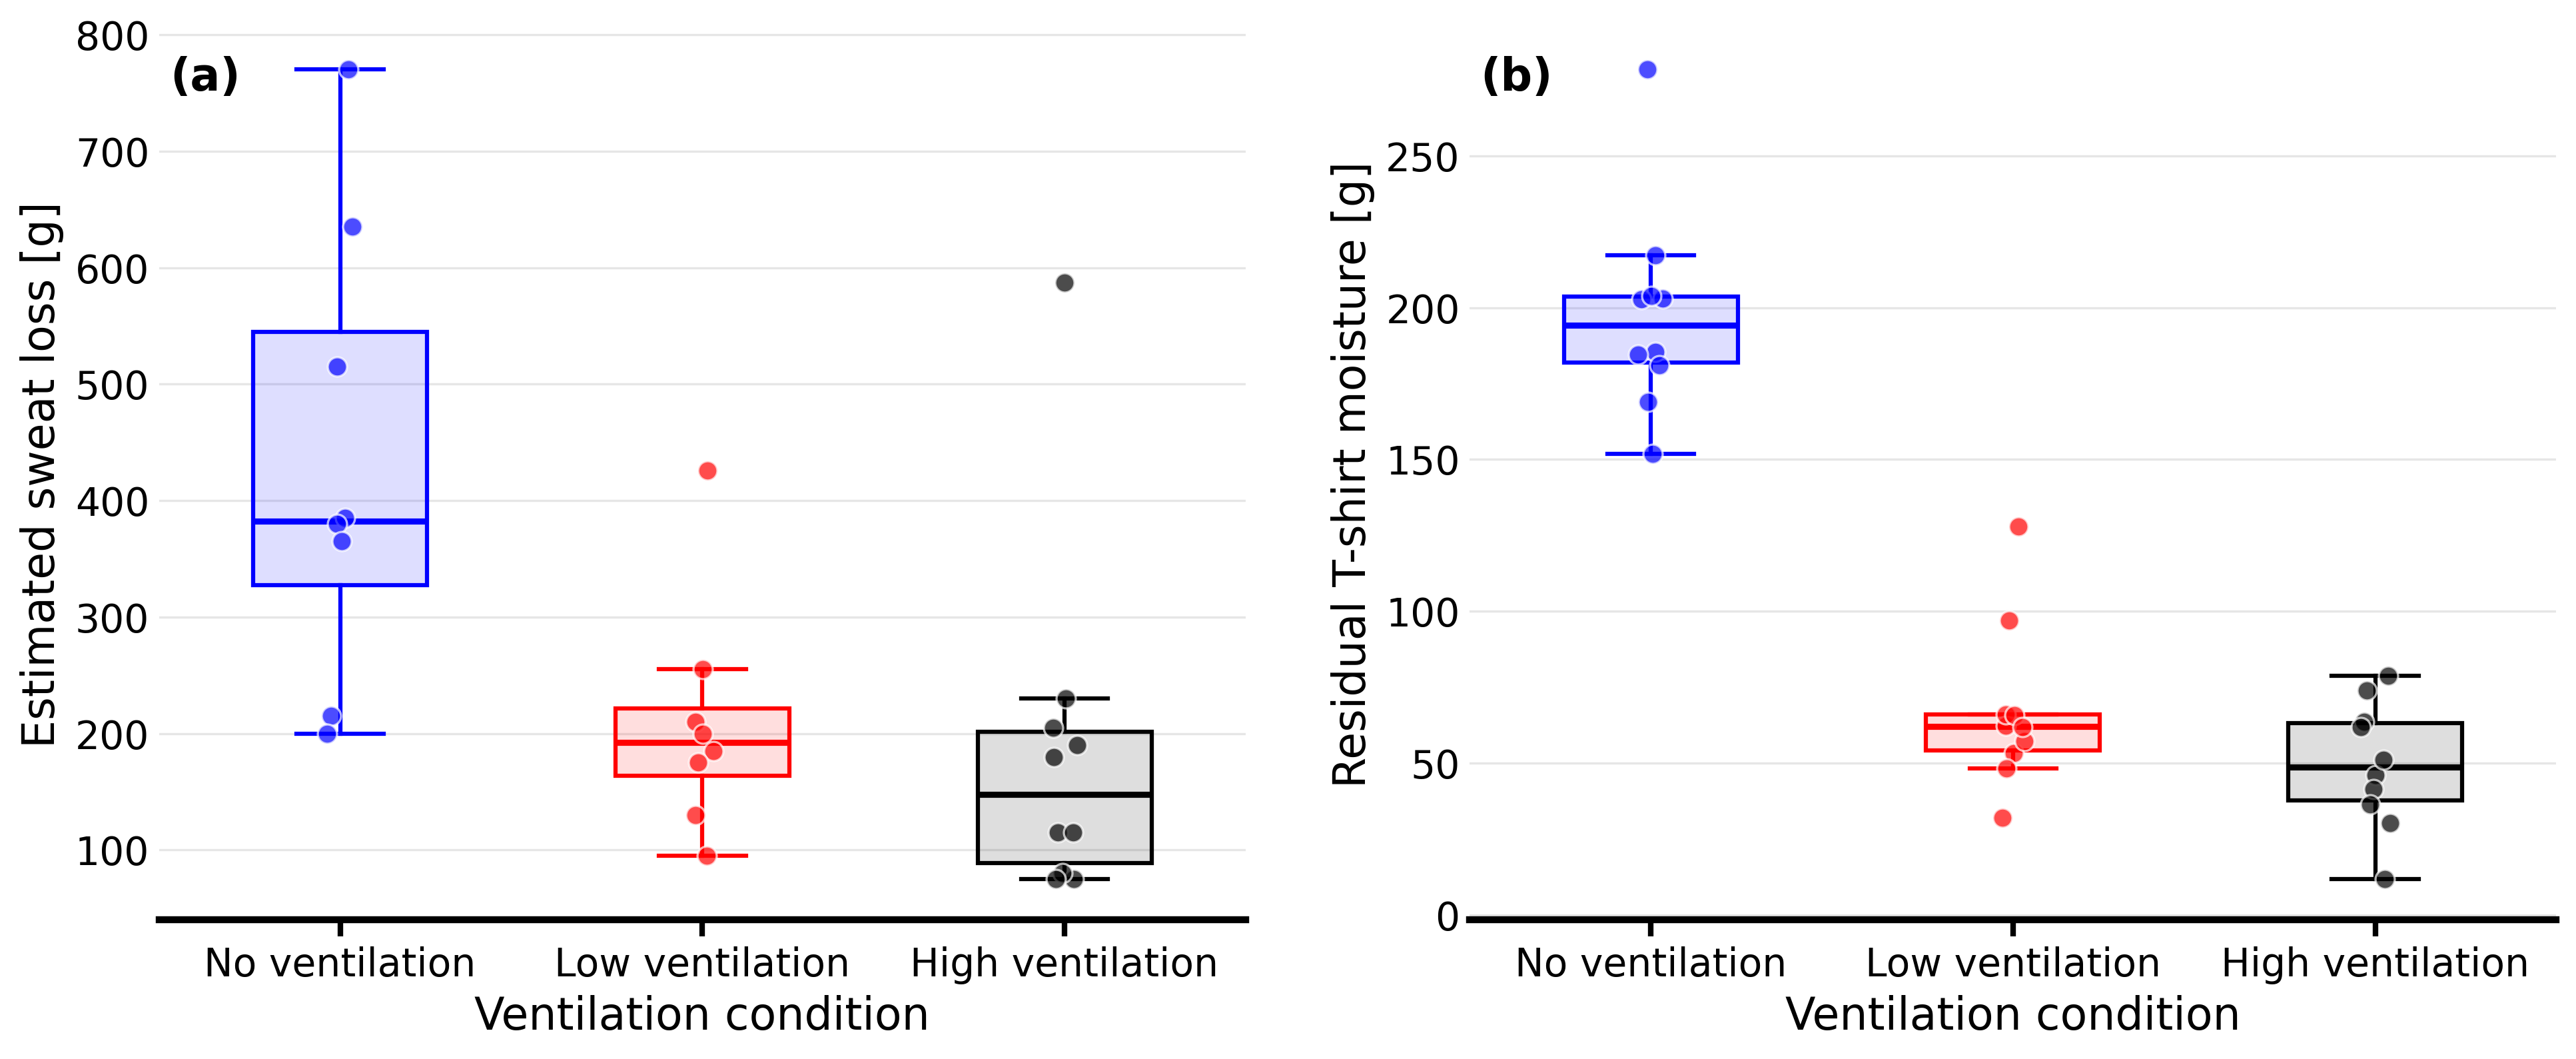

Figure saved to: /home/eleonorab/repository/convective_cooling/reports/08_sweat_mass_balance/sweat_loss_and_shirt_moisture.png


In [4]:
def style_axis(ax, ylabel):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.tick_params(axis="both", labelsize=14)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", width=2.0, length=6)
    ax.set_xlabel("Ventilation condition", fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.grid(axis="y", color="0.90", linewidth=0.8, zorder=0)


def paired_panel(ax, table, outcome, validity, ylabel):
    plot_data = table.loc[table[validity], ["subject_id", "condition", outcome]].copy()
    x_map = {condition: i for i, condition in enumerate(CONDITION_ORDER)}

    rng = np.random.default_rng(20260908)
    for condition in CONDITION_ORDER:
        values = plot_data.loc[plot_data["condition"].eq(condition), outcome].dropna().to_numpy()
        color = CONDITION_COLORS[condition]
        if len(values):
            ax.boxplot(
                values,
                positions=[x_map[condition]],
                widths=0.48,
                patch_artist=True,
                showfliers=False,
                boxprops={
                    "facecolor": to_rgba(color, 0.13),
                    "edgecolor": color,
                    "linewidth": 1.5,
                },
                medianprops={"color": color, "linewidth": 2.2},
                whiskerprops={"color": color, "linewidth": 1.5},
                capprops={"color": color, "linewidth": 1.5},
                zorder=2,
            )
        jitter = rng.uniform(-0.045, 0.045, len(values))
        ax.scatter(
            x_map[condition] + jitter, values, s=48,
            color=color, edgecolor="white", linewidth=0.8,
            alpha=0.7, zorder=3,
        )

    ax.set_xticks(range(len(CONDITION_ORDER)))
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
    style_axis(ax, ylabel)


fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), dpi=300)
paired_panel(
    axes[0], clean, "estimated_sweat_loss_g", "body_analysis_ok",
    "Estimated sweat loss [g]",
)
paired_panel(
    axes[1], clean, "shirt_retained_moisture_g", "shirt_analysis_ok",
    "Residual T-shirt moisture [g]",
)
axes[0].text(0.01, 0.97, "(a)", transform=axes[0].transAxes, va="top", fontsize=16, fontweight="bold")
axes[1].text(0.01, 0.97, "(b)", transform=axes[1].transAxes, va="top", fontsize=16, fontweight="bold")
fig.tight_layout(w_pad=3.0)

figure_path = OUTPUT_DIR / "sweat_loss_and_shirt_moisture.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {figure_path}")


## 5. Interpretation checklist

- A lower T-shirt mass gain under ventilation is consistent with less moisture retained by the fabric, but is not by itself a direct measurement of evaporation.
- Similar estimated sweat loss combined with lower T-shirt moisture would be consistent with ventilation enhancing moisture removal.
- Differences in estimated sweat loss may reflect altered thermoregulatory sweating, measurement uncertainty, or both.
- Final reporting should state the balance precision, the timing of post-trial weighing, and whether participants were weighed without wet garments.
